In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from pybaseball import lahman
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
mlb25_pd = pd.read_csv("2025MLBplatediscipline.csv")
mlb24_pd = pd.read_csv("2024MLBplatediscipline.csv")
mlb23_pd = pd.read_csv("2023MLBplatediscipline.csv")
mlb22_pd = pd.read_csv("2022MLBplatediscipline.csv")
mlb21_pd = pd.read_csv("2021MLBplatediscipline.csv")

In [3]:
mlb_plate_discipline = pd.concat([mlb25_pd, mlb24_pd, mlb23_pd, mlb22_pd, mlb21_pd])
mlb_plate_discipline

,Team,Wins,Losses,Season,Pitches,Zone%,Zone Swing,Zone Contact,Chase%,Chase Contact,Edge,1st Pitch Swing,Swing%,Whiff%,Meatball,Meatball Swing
0,Colorado Rockies,43,119,2025,"22,447",50.2,70.1,80.6,31.7,49.6,42.7,36.3,51.0,29.0,7.6,77.6
1,Cleveland Guardians,88,74,2025,"23,330",50.6,67.0,82.3,29.5,57.2,42.8,30.3,48.5,25.2,7.8,76.6
2,Washington Nationals,66,96,2025,"22,888",51.2,66.3,83.4,29.0,54.2,43.0,33.5,48.1,25.2,7.8,75.6
3,Chicago White Sox,60,102,2025,"23,243",51.2,67.3,81.9,27.8,56.7,43.8,33.9,48.0,25.2,8.0,78.0
4,Los Angeles Angels,72,90,2025,"23,764",50.6,66.9,80.5,27.3,48.5,43.0,34.4,47.3,28.6,7.5,76.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25,Cincinnati Reds,83,79,2021,"24,111",47.8,67.9,82.2,28.5,56.3,42.5,32.8,47.3,26.0,7.1,77.9
26,San Francisco Giants,107,55,2021,"24,617",49.7,68.3,81.3,24.2,56.3,42.7,30.3,46.1,25.4,7.5,79.9
27,Tampa Bay Rays,100,62,2021,"24,326",48.3,69.5,78.6,27.0,55.3,42.4,31.3,47.6,28.3,7.4,81.2
28,Los Angeles Dodgers,106,56,2021,"24,466",50.0,67.5,81.8,23.7,55.5,42.6,28.9,45.6,25.0,7.8,78.0


In [4]:
team_summary = mlb_plate_discipline.groupby('Team').agg({'Wins': 'sum', 'Losses': 'sum', 'Chase%': 'mean'}).reset_index()
team_summary['Winpct'] = team_summary['Wins'] / (team_summary['Wins'] + team_summary['Losses'])
team_summary

,Team,Wins,Losses,Chase%,Winpct
0,Arizona Diamondbacks,379,431,26.84,0.467901
1,Athletics,341,469,28.16,0.420988
2,Atlanta Braves,458,351,29.28,0.566131
3,Baltimore Orioles,402,408,29.56,0.496296
4,Boston Red Sox,418,392,29.66,0.516049
5,Chicago Cubs,403,407,27.60,0.497531
6,Chicago White Sox,336,474,30.62,0.414815
7,Cincinnati Reds,387,423,27.66,0.477778
8,Cleveland Guardians,428,381,30.26,0.529048
9,Colorado Rockies,305,504,31.12,0.377009


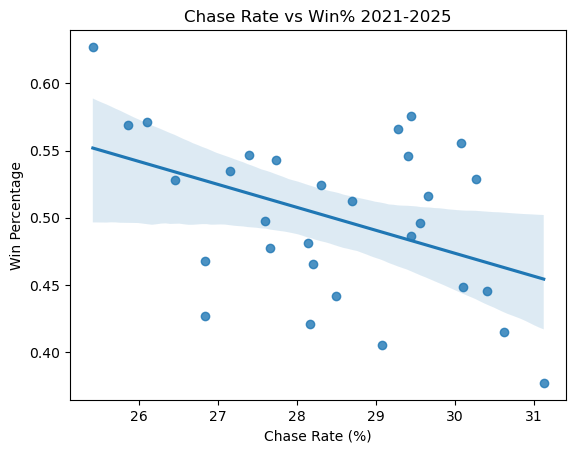

In [5]:
sns.regplot(x=team_summary['Chase%'], y=team_summary['Winpct'])

plt.xlabel('Chase Rate (%)')
plt.ylabel('Win Percentage')
plt.title('Chase Rate vs Win% 2021-2025');

In [6]:
standard_batting25 = pd.read_csv("2025standardbatting.csv")
standard_batting24 = pd.read_csv("2024standardbatting.csv")
standard_batting23 = pd.read_csv("2023standardbatting.csv")
standard_batting22 = pd.read_csv("2022standardbatting.csv")
standard_batting21 = pd.read_csv("2021standardbatting.csv")
mlb_standard_batting = pd.concat([standard_batting21, standard_batting22, standard_batting23, standard_batting24, standard_batting25])


In [7]:
mlb_batting_discipline = pd.merge(mlb_plate_discipline, mlb_standard_batting, on =['Team', 'Season'], how='left')
mlb_batting_discipline['Winpct'] = mlb_batting_discipline['Wins'] / (mlb_batting_discipline['Wins'] + mlb_batting_discipline['Losses'])

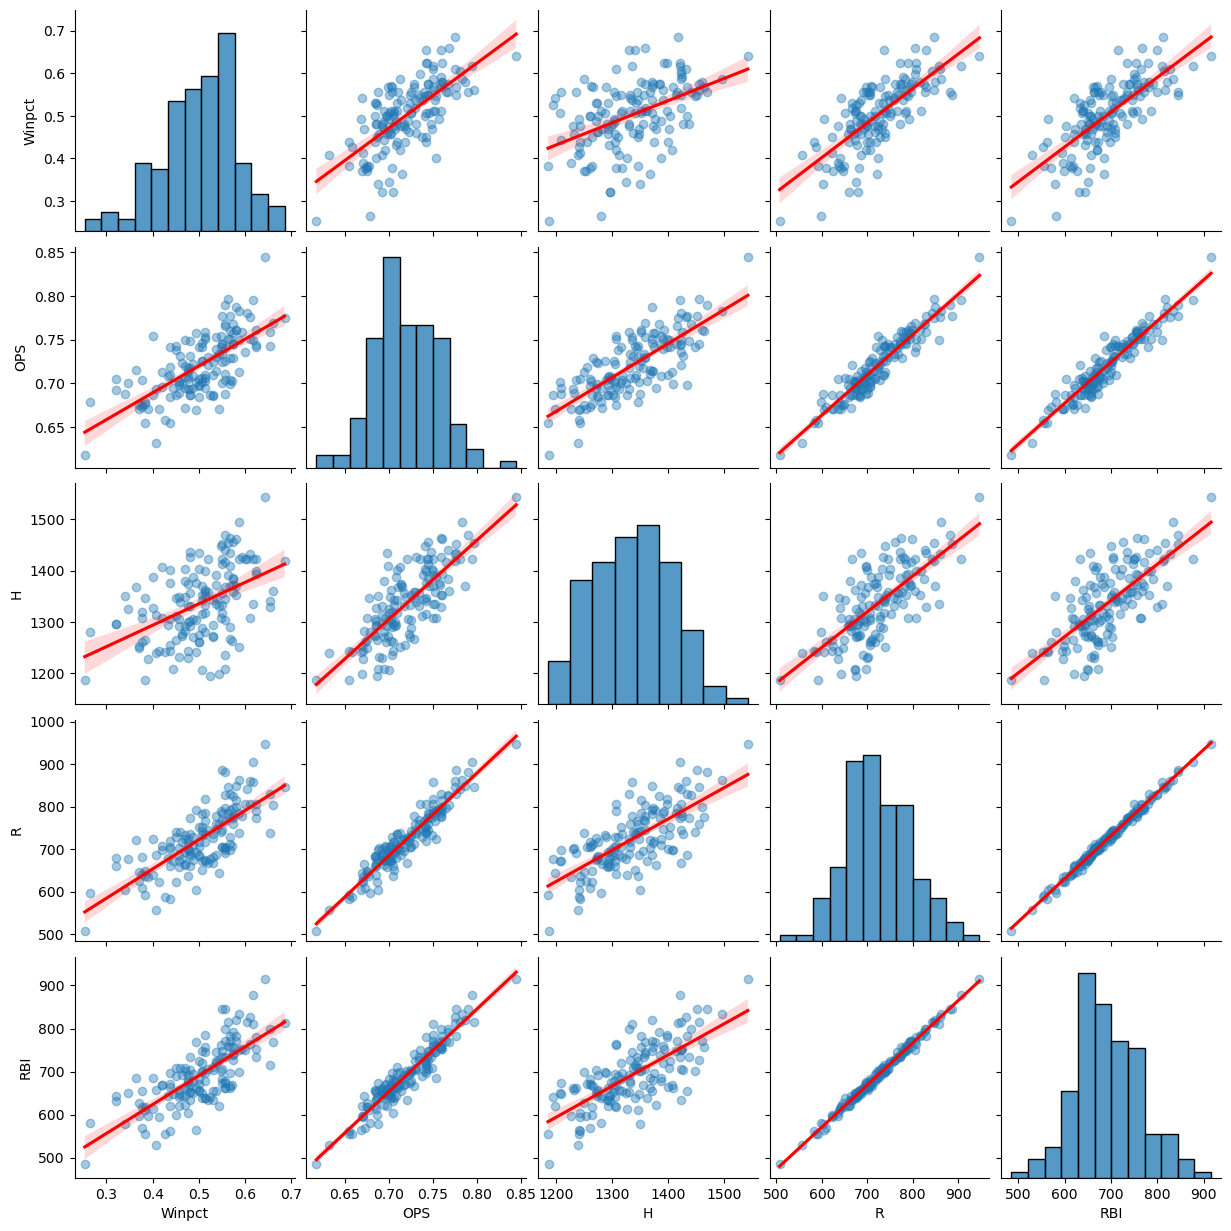

In [13]:
mlb_pairplot = mlb_batting_discipline[['Winpct', 'OPS', 'H', 'R', 'RBI']]
sns.pairplot(mlb_pairplot, kind="reg", plot_kws={"scatter_kws": {"alpha": .4}, "line_kws":{"color": "red"}})

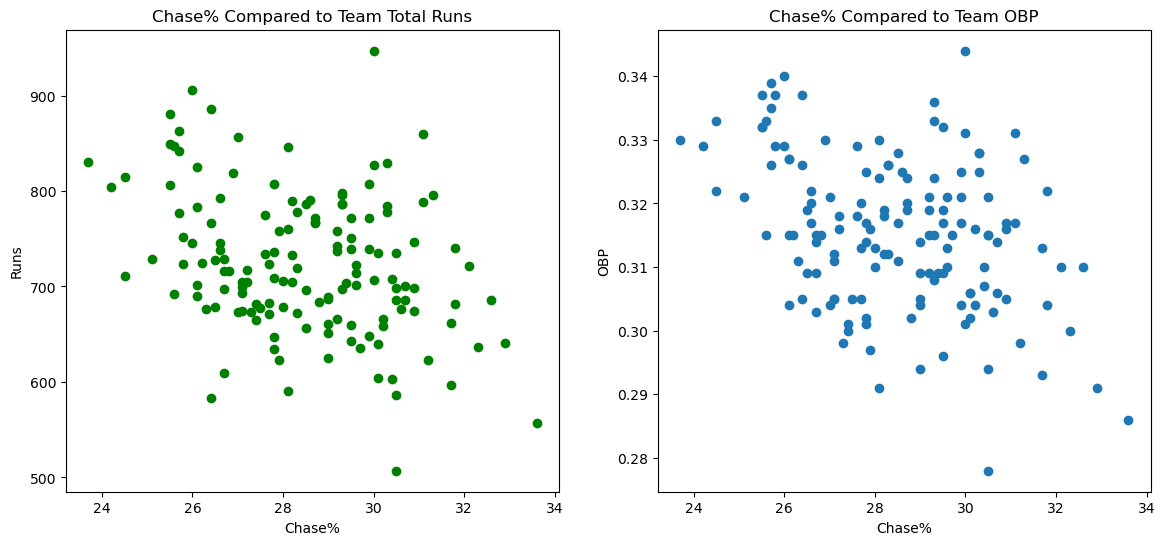

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(mlb_batting_discipline['Chase%'], mlb_batting_discipline['R'], color = "green")
axes[0].set_title("Chase% Compared to Team Total Runs")
axes[0].set_xlabel("Chase%")
axes[0].set_ylabel("Runs")
axes[1].scatter(mlb_batting_discipline['Chase%'], mlb_batting_discipline['OBP'])
axes[1].set_title("Chase% Compared to Team OBP")
axes[1].set_xlabel("Chase%")
axes[1].set_ylabel("OBP");

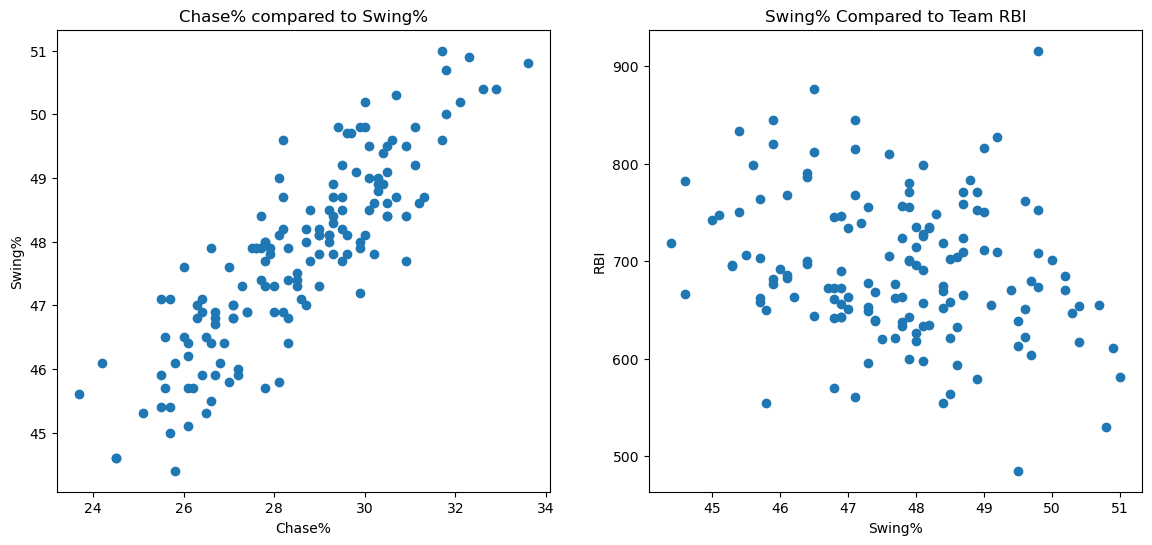

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(mlb_batting_discipline['Chase%'], mlb_batting_discipline['Swing%'])
axes[0].set_title("Chase% compared to Swing%")
axes[0].set_xlabel("Chase%")
axes[0].set_ylabel("Swing%")
axes[1].scatter(mlb_batting_discipline['Swing%'], mlb_batting_discipline['RBI'])
axes[1].set_title("Swing% Compared to Team RBI")
axes[1].set_xlabel("Swing%")
axes[1].set_ylabel("RBI");

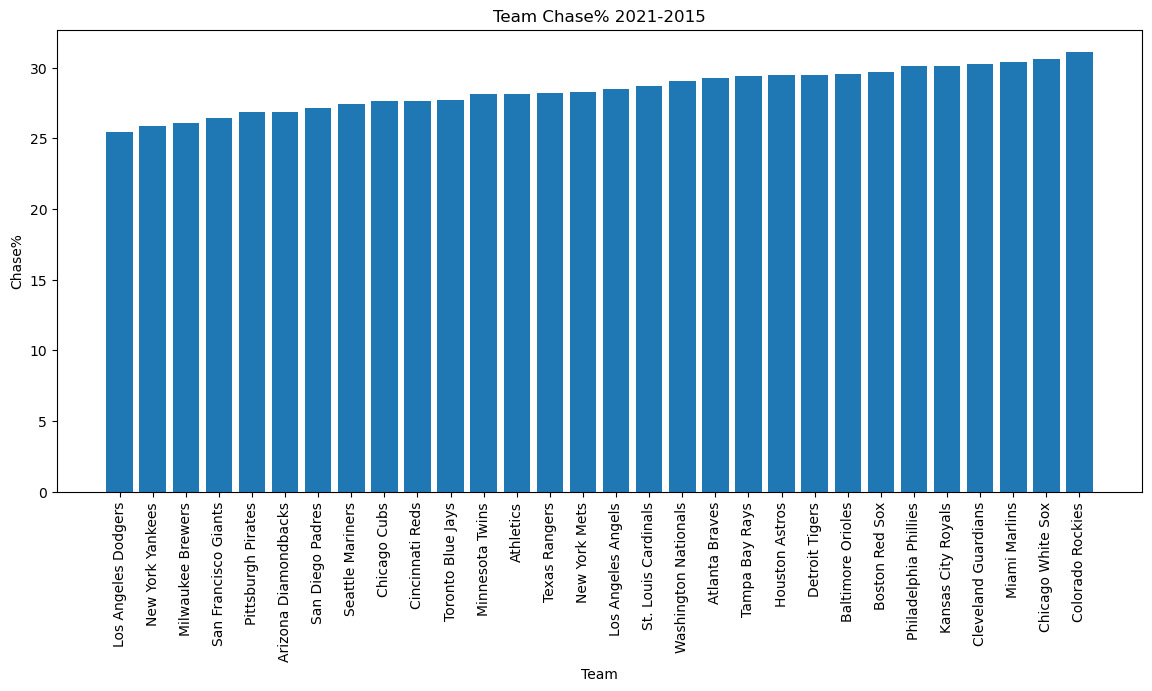

In [11]:
team_chase = team_summary.sort_values('Chase%')
plt.figure(figsize=(14,6))
plt.bar(team_chase['Team'], team_chase['Chase%'])
plt.title("Team Chase% 2021-2015")
plt.xlabel("Team")
plt.ylabel("Chase%")
plt.xticks(rotation=90);

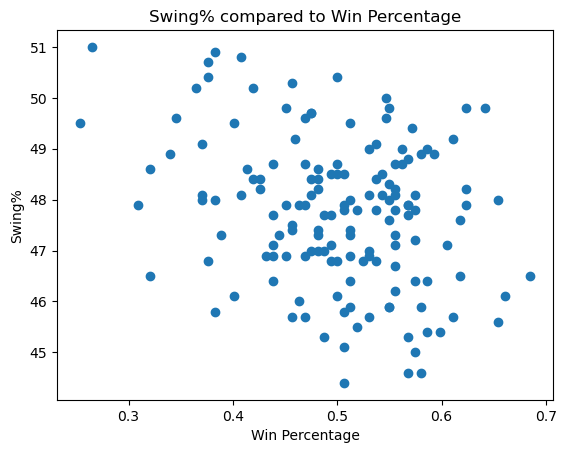

In [12]:
plt.scatter(mlb_batting_discipline['Winpct'], mlb_batting_discipline['Swing%'])
plt.title("Swing% compared to Win Percentage")
plt.xlabel("Win Percentage")
plt.ylabel("Swing%");